# Analyse Exploratoire (EDA) - Telco Customer Churn

**Problématique :** Comment prédire qu'un client va résilier (churn) son abonnement télécom à partir de ses caractéristiques (services souscrits, contrat, facturation, ancienneté) ?

**Source du dataset :** Publié initialement par IBM, largement utilisé en recherche et en formation (référencé sur Kaggle : *Telco Customer Churn* par blastchar). Source externe justifiée par rapport aux sources recommandées : dataset propre, taille suffisante (7043 lignes, 21 variables), problématique métier claire et pertinente (rétention client), absent des sources locales tunisiennes.

## 1. Import des bibliothèques

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

## 2. Chargement des données

In [2]:
df = pd.read_csv("../data/raw/Telco-Customer-Churn.csv")
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Analyse des données

### 3.1 Structure générale

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
# TotalCharges est en object alors qu'il devrait être numérique -> à corriger en preprocessing
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print("Valeurs manquantes après conversion :", df['TotalCharges'].isna().sum())

Valeurs manquantes après conversion : 11


### 3.2 Valeurs manquantes et doublons

In [5]:
print("Doublons (customerID) :", df['customerID'].duplicated().sum())
df.isna().sum().sort_values(ascending=False).head(10)

Doublons (customerID) : 0


TotalCharges      11
gender             0
SeniorCitizen      0
Partner            0
customerID         0
Dependents         0
tenure             0
MultipleLines      0
PhoneService       0
OnlineSecurity     0
dtype: int64

### 3.3 Distribution de la variable cible (Churn)

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


/tmp/ipykernel_606/1249697049.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette='Set2')


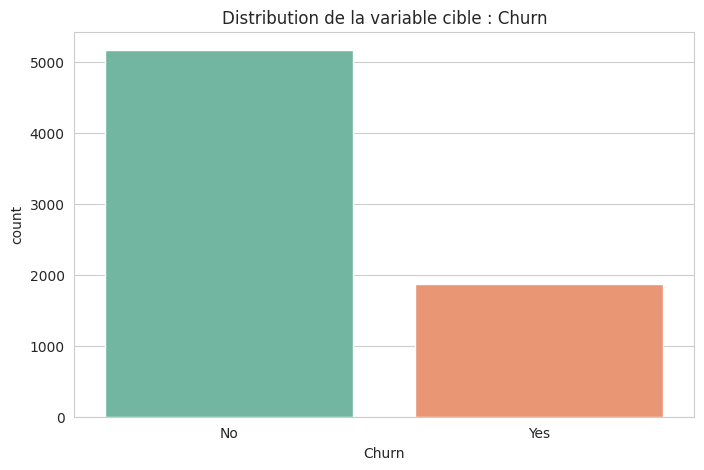

In [6]:
churn_counts = df['Churn'].value_counts(normalize=True) * 100
print(churn_counts)

plt.figure()
sns.countplot(data=df, x='Churn', palette='Set2')
plt.title("Distribution de la variable cible : Churn")
plt.savefig("../categorical_target.png", dpi=120, bbox_inches='tight')
plt.show()

**Observation :** classes déséquilibrées (~26% churn / ~74% non-churn) -> à garder en tête pour le choix des métriques (Recall/F1 plutôt que seule Accuracy) et éventuellement pour le rééquilibrage en preprocessing.

### 3.4 Distributions des variables numériques

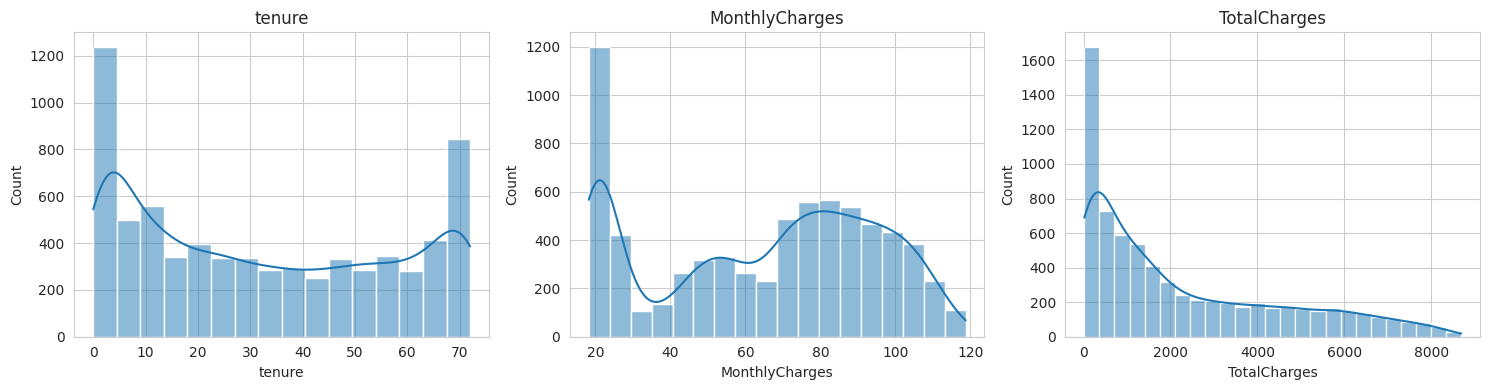

In [7]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, num_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.savefig("../numeric_distributions.png", dpi=120, bbox_inches='tight')
plt.show()

### 3.5 Boxplots (détection visuelle des outliers)

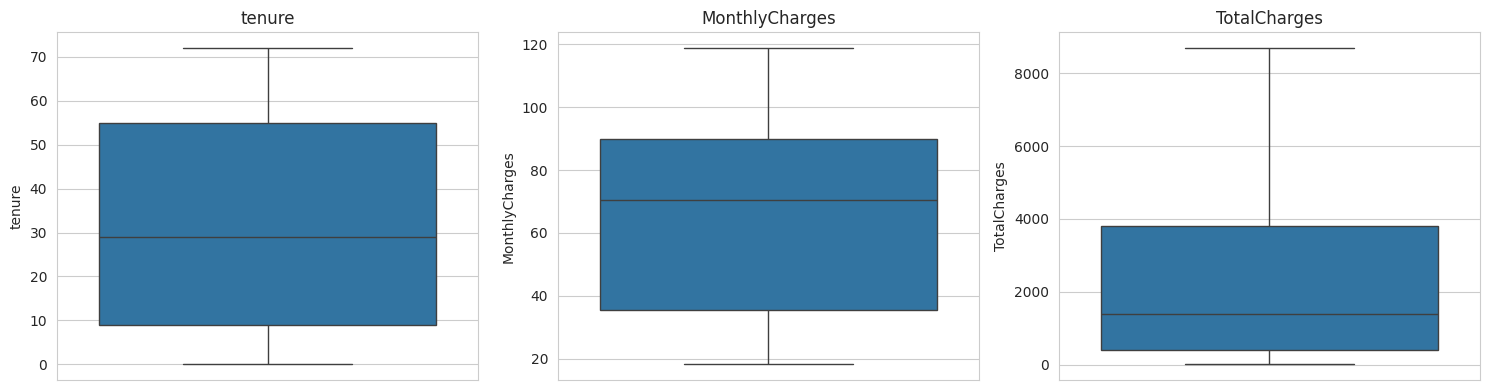

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, num_cols):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.savefig("../boxplots.png", dpi=120, bbox_inches='tight')
plt.show()

### 3.6 Corrélation entre variables numériques et churn

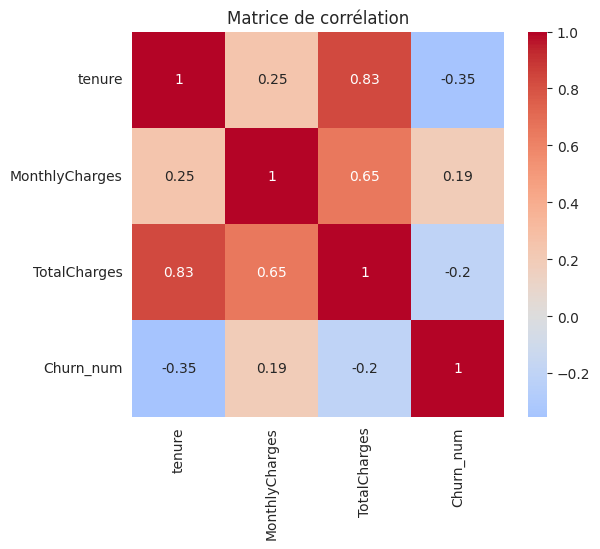

In [9]:
df_corr = df.copy()
df_corr['Churn_num'] = (df_corr['Churn'] == 'Yes').astype(int)

corr = df_corr[num_cols + ['Churn_num']].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title("Matrice de corrélation")
plt.savefig("../correlation_matrix.png", dpi=120, bbox_inches='tight')
plt.show()

**Observation :** `tenure` est négativement corrélée au churn (plus un client est ancien, moins il résilie) ; `MonthlyCharges` est positivement corrélée (factures élevées -> plus de résiliation).

### 3.7 Variables catégorielles vs Churn

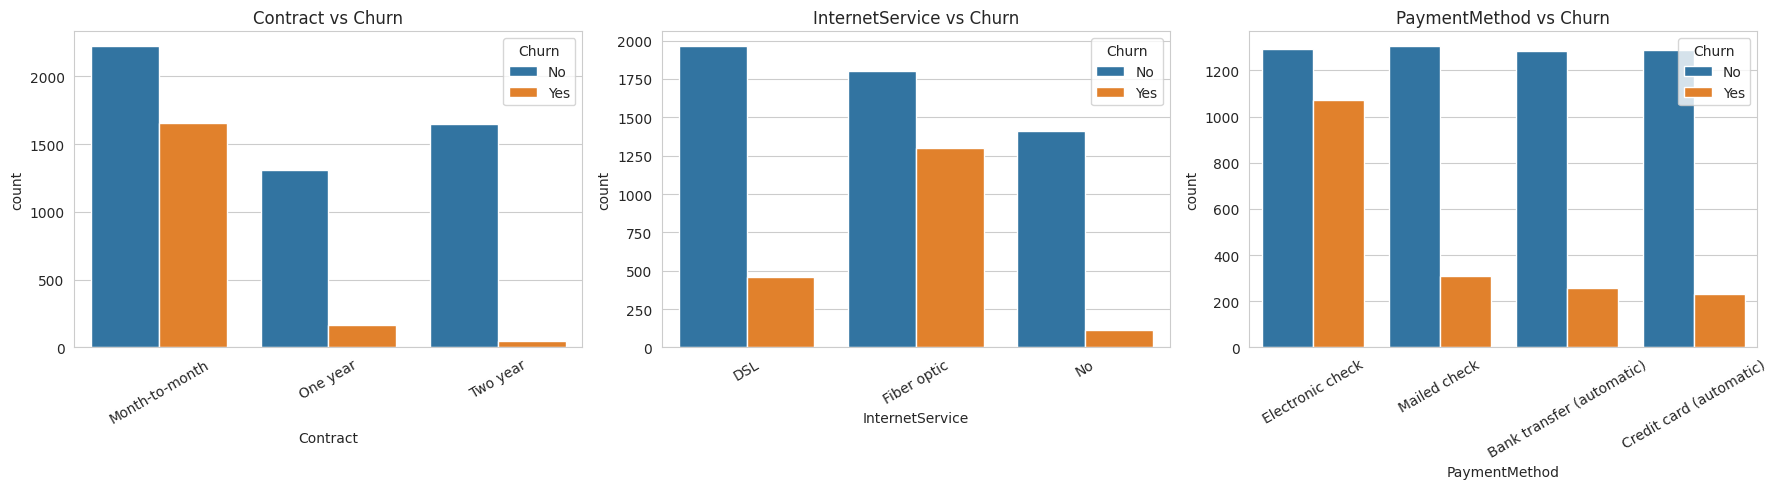

In [10]:
cat_cols = ['Contract', 'InternetService', 'PaymentMethod']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, cat_cols):
    sns.countplot(data=df, x=col, hue='Churn', ax=ax)
    ax.set_title(f"{col} vs Churn")
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig("../target_analysis.png", dpi=120, bbox_inches='tight')
plt.show()

**Observation :** les clients en contrat "Month-to-month" résilient beaucoup plus que ceux en contrat 1 ou 2 ans -> variable probablement très importante pour le modèle.

## Conclusion de l'EDA
- Dataset propre dans l'ensemble, peu de valeurs manquantes (à corriger sur `TotalCharges`)
- Classes légèrement déséquilibrées
- `tenure`, `Contract` et `MonthlyCharges` semblent être des variables fortement liées au churn
- Prochaine étape : notebook `02_preprocessing_draft.ipynb` (nettoyage, encodage, split)